In [ ]:
import sys
import vaex
import pandas as pd
import matplotlib.pyplot as plt
from pytz import timezone

sys.path.append("../")


def configure_dual_time_xaxis(
    ax,
    *,
    tz_utc="UTC",
    tz_local="America/Sao_Paulo",
    secondary_offset_pts=36,
    label_utc=None,
    label_local=None,
):
    from zoneinfo import ZoneInfo
    import numpy as np
    import pandas as pd
    import matplotlib.dates as mdates

    tz_utc = ZoneInfo(str(tz_utc))
    tz_local = ZoneInfo(str(tz_local))

    locator = mdates.AutoDateLocator()

    # --- Primary axis (UTC): keep defaults ---
    ax.set_xlabel(label_utc or str(tz_utc))
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.AutoDateFormatter(locator, tz=tz_utc))

    # --- Internal conversion helper (shape-safe) ---
    def _convert_mdates_num(x, *, src_tz, dst_tz):
        x_arr = np.asarray(x, dtype=float)
        x_flat = x_arr.reshape(-1)

        dts = mdates.num2date(x_flat)
        idx = pd.DatetimeIndex(dts)

        if idx.tz is None:
            idx = idx.tz_localize(src_tz)
        else:
            idx = idx.tz_convert(src_tz)

        idx2 = idx.tz_convert(dst_tz)
        y_flat = mdates.date2num(idx2.to_pydatetime()).astype(float)

        y = y_flat.reshape(x_arr.shape)
        if np.isscalar(x):
            return float(y_flat[0])
        return y

    def utc_to_local(x):
        return _convert_mdates_num(x, src_tz=tz_utc, dst_tz=tz_local)

    def local_to_utc(x):
        return _convert_mdates_num(x, src_tz=tz_local, dst_tz=tz_utc)

    # --- Secondary axis (Local time): keep defaults ---
    secax = ax.secondary_xaxis(
        "bottom",
        functions=(utc_to_local, local_to_utc),
    )
    secax.minorticks_off()
    secax.spines["bottom"].set_position(("outward", secondary_offset_pts))
    secax.set_xlabel(label_local or f"Local time ({tz_local})")

    secax.xaxis.set_major_locator(locator)
    secax.xaxis.set_major_formatter(mdates.AutoDateFormatter(locator, tz=tz_local))

    return secax

In [ ]:
SIGNAL = "MT19__RPM__AVG"

PATH1 = "../data/parsed/sparse/candump-2020-02-*.log_chunk_*.hdf5"
df1 = vaex.open(PATH1).to_pandas_df()[["timestamp", SIGNAL]].dropna()

print("original:                      ", df1["timestamp"].min())
print(
    "localized(tz):                 ",
    df1["timestamp"].dt.tz_localize("America/Sao_Paulo").min(),
)
print(
    "localize(tz) -> localize(None):",
    df1["timestamp"].dt.tz_localize("America/Sao_Paulo").dt.tz_localize(None).min(),
)

original:                                       2020-02-01 00:20:21.542795897
localized(tz):                                  2020-02-01 00:20:21.542795897-03:00
localize(tz) -> convert(None):                  2020-02-01 03:20:21.542795897
localize(tz) -> localize(None):                 2020-02-01 00:20:21.542795897
localize(tz) -> convert(UTC) -> localize(None): 2020-02-01 03:20:21.542795897


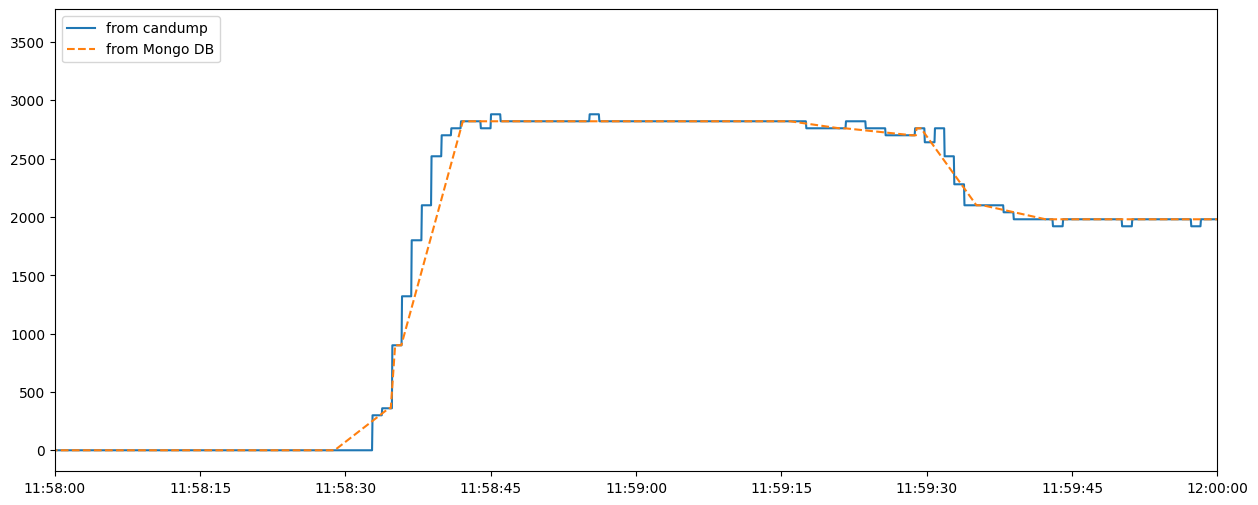

CPU times: user 7.57 s, sys: 3.71 s, total: 11.3 s
Wall time: 11.3 s


In [ ]:
%%time

SIGNAL = "MT19__RPM__AVG"
t_start = pd.Timestamp("2020-02-02 11:58:00", tz='America/Sao_Paulo')
t_end = pd.Timestamp("2020-02-02 12:00:00", tz='America/Sao_Paulo')

PATH1 = "../data/parsed/sparse/candump-2020-02-*.log_chunk_*.hdf5"
df1 = vaex.open(PATH1).to_pandas_df()[["timestamp", SIGNAL]].dropna()
df1['timestamp'] = pd.to_datetime(df1['timestamp']).dt.tz_localize('America/Sao_Paulo')
df1 = df1.set_index("timestamp").sort_index()
PATH2 = "../data/parsed/sparse/candump-from_db*.log_chunk_*.hdf5"
df2 = vaex.open(PATH2).to_pandas_df()[["timestamp", SIGNAL]].dropna()
df2['timestamp'] = pd.to_datetime(df2['timestamp']).dt.tz_localize('America/Sao_Paulo')
df2 = df2.set_index("timestamp").sort_index()

fig = plt.figure(figsize=(15,6))
plt.plot(df1.index, df1[SIGNAL], label="from candump")
plt.plot(df2.index, df2[SIGNAL], '--', label="from Mongo DB")
plt.xlim([t_start, t_end])
configure_dual_time_xaxis(ax=fig.axes[0], tz_utc="UTC", tz_local="America/Sao_Paulo")
plt.legend(loc='upper left')
plt.show()

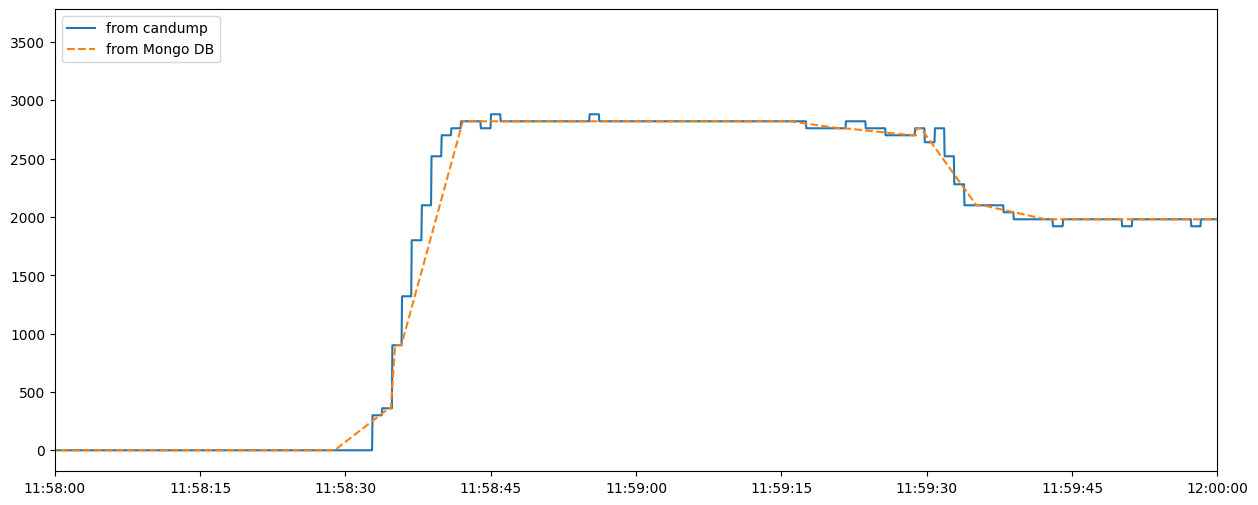

CPU times: user 3.13 s, sys: 2.96 s, total: 6.1 s
Wall time: 6.04 s


In [ ]:
%%time

SIGNAL = "MT19__RPM__AVG"
t_start = pd.Timestamp("2020-02-02 11:58:00")
t_end = pd.Timestamp("2020-02-02 12:00:00")

PATH1 = "../data/parsed/sparse/candump-2020-02-*.log_chunk_*.hdf5"
df1 = vaex.open(PATH1).to_pandas_df()[["timestamp", SIGNAL]].dropna()
df1['timestamp'] = pd.to_datetime(df1['timestamp'])
df1 = df1.set_index("timestamp").sort_index()
PATH2 = "../data/parsed/sparse/candump-from_db*.log_chunk_*.hdf5"
df2 = vaex.open(PATH2).to_pandas_df()[["timestamp", SIGNAL]].dropna()
df2['timestamp'] = pd.to_datetime(df2['timestamp'])
df2 = df2.set_index("timestamp").sort_index()

fig = plt.figure(figsize=(15,6))
plt.plot(df1.index, df1[SIGNAL], label="from candump")
plt.plot(df2.index, df2[SIGNAL], '--', label="from Mongo DB")
plt.xlim([t_start, t_end])
plt.legend(loc='upper left')
plt.show()